Q4  

This is a simple Question-Answering (QA) System using the Chroma vector database.  

The documents that we collect are from personal comments on course presentation.  
So, we design some related questions and find answer on Chroma vector database.  

**Note: run in colab**

In [ ]:
!pip install chromadb
!pip install transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.8 MB/s eta 0:00:00

In [ ]:
import chromadb
# create a database based on chromadb
chroma_client = chromadb.Client()

In [ ]:
# 建立 Collection（像是一個資料表）
collection = chroma_client.create_collection(name="HW4_collection")

In [ ]:
# 建立文章
documents = [
    "他們給足了很多背景知識，像是第四頁當中有提到 2007 年還有一次能登半島地震。",
    "關於本次的重點──2024 年能登半島地震，也是非常詳細地說明。",
    "他們解釋了逆斷層地震，加上地形淺層的關係，讓地震災情非常嚴重。",
    "講到這兩點，讓我想到台灣也是這樣的地質結構。",
    "例如台灣西部也是淺層的地震，加上台灣又是逆斷層組成的小島。",
    "因此能登半島地震的警示，我認為台灣可以好好參考一下。",
    "談到對台灣的啟示，我對於災後救援與國際合作據力這點感到非常有感觸。",
    "我發現日本的諸多大地震當中，國際合作的救援力量是非常重要的。",
    "例如 311 大地震期間，國際間派出了許多救援隊來到日本協助救災。",
    "這讓我思考，若台灣也發生如此大規模的地震時，我們要怎麼加強國內救援隊的救災能力。",
    "同時也需要建立強大的外援網路。",
    "這些因素都讓我覺得災前教育跟其他相關的事前準備是非常重要的一環。",
    "2024 年能登半島地震是發生在石川縣的,因為這個地震反而讓觀光客外流甚至人口外流更加嚴重。",
    "這組有講到日本的颱風災害為哈吉貝颱風。",
]

In [ ]:
collection.add(documents=documents, ids=[f"doc{i}" for i in range(len(documents))])

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:02<00:00, 32.1MiB/s]


In [ ]:
query_text = ["能登半島地震發生時間?", "心得中提到對台灣的啟示是甚麼?", "日本有過颱風災害?"]

In [ ]:
for query_num in range(len(query_text)):
  query = query_text[query_num]
  print(f"問題 {query_num+1}: {query}")
  results = collection.query(query_texts=[query], n_results=3)
  for i, sentence in enumerate(results['documents'][0]):
      print(f"\t答案第 {i+1} 句：{sentence}")
  print() # for empty line

問題 1: 能登半島地震發生時間?
	答案第 1 句：關於本次的重點──2024 年能登半島地震，也是非常詳細地說明。
	答案第 2 句：因此能登半島地震的警示，我認為台灣可以好好參考一下。
	答案第 3 句：例如 311 大地震期間，國際間派出了許多救援隊來到日本協助救災。

問題 2: 心得中提到對台灣的啟示是甚麼?
	答案第 1 句：談到對台灣的啟示，我對於災後救援與國際合作據力這點感到非常有感觸。
	答案第 2 句：因此能登半島地震的警示，我認為台灣可以好好參考一下。
	答案第 3 句：這讓我思考，若台灣也發生如此大規模的地震時，我們要怎麼加強國內救援隊的救災能力。

問題 3: 日本有過颱風災害?
	答案第 1 句：這組有講到日本的颱風災害為哈吉貝颱風。
	答案第 2 句：例如 311 大地震期間，國際間派出了許多救援隊來到日本協助救災。
	答案第 3 句：談到對台灣的啟示，我對於災後救援與國際合作據力這點感到非常有感觸。



Implemented RAG (Retrival-Augmented Generation)  
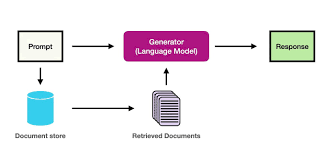

In [ ]:
from transformers import pipeline
qa_model = pipeline("text2text-generation")

No model was supplied, defaulted to google-t5/t5-base and revision a9723ea (https://huggingface.co/google-t5/t5-base).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
# ask user to enter the question
# EX: 能登半島地震發生時間?
print("Type your questions:", end=' ')
query =[input()]
# Get query from the database
results = collection.query(query_texts=query, n_results=2)

# contact context
context = "\n".join(results['documents'][0])
print("context:", context)

# 合併成一段 prompt 給模型
prompt = f"請根據以下段落回答問題：\n{context}\n\n問題:{query[0]}"

# 用生成模型回答
response = qa_model(prompt)[0]['generated_text']
print("生成回答：", response)

Type your questions: 能登半島地震發生時間?
context: 關於本次的重點──2024 年能登半島地震，也是非常詳細地說明。
因此能登半島地震的警示，我認為台灣可以好好參考一下。
生成回答： 2024 , , , :
